# Apache Log Anomaly Analysis

This notebook demonstrates how to use the log anomaly analysis pipeline for Apache logs.

In [1]:
import sys
import os
sys.path.append('../..')

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from log_anomaly_analysis import ModularPipeline
from log_anomaly_analysis.visualization.plots import (
    plot_timeseries, plot_histogram, plot_event_heatmap, plot_tsne, create_analysis_dashboard
)

plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Run the Pipeline

In [ ]:
# Run the pipeline
pipeline = ModularPipeline("../../configs/apache/sliding.yaml")
results, summary = pipeline.run()

# Display summary
print("Pipeline Summary:")
for key, value in summary.items():
    print(f"{key}: {value}")

2025-10-05 23:07:53.261 | INFO     | log_anomaly_analysis.core.modular_pipeline:_initialize_components:40 - Initializing pipeline components
2025-10-05 23:07:53.270 | INFO     | log_anomaly_analysis.core.modular_pipeline:__init__:36 - Pipeline initialized with output directory: /home/mih/cs/elfak/diplomski/log-anomaly-analysis/log-anomaly-analysis/data/results/apache_sliding/20251005-230753
2025-10-05 23:07:53.271 | INFO     | log_anomaly_analysis.core.modular_pipeline:run:52 - Starting modular anomaly detection pipeline
2025-10-05 23:07:53.271 | INFO     | log_anomaly_analysis.core.modular_pipeline:run:57 - Loading dataset...
2025-10-05 23:07:53.271 | INFO     | log_anomaly_analysis.datasets.loaders:load_dataset:18 - Loading dataset from /home/mih/cs/elfak/diplomski/log-anomaly-analysis/log-anomaly-analysis/data/raw/loghub_2k/Apache/Apache_2k.log
2025-10-05 23:07:53.274 | INFO     | log_anomaly_analysis.datasets.loaders:_load_file_dataset:40 - Loaded 2000 raw log lines
2025-10-05 23:0

Pipeline Summary:
total_logs: 2000
unique_templates: 5
total_windows: 425
anomalous_windows: 3
anomaly_rate: 0.007058823529411765
run_timestamp: 20251005-230753


## 2. Analyze Results

In [3]:
# Get anomaly results
anomalies = results['anomalies']
print(f"Anomaly detection results shape: {anomalies.shape}")
print(f"Columns: {anomalies.columns}")

Anomaly detection results shape: (425, 12)
Columns: ['Window', 'workerEnv.init() ok < PATH >', 'mod jk child workerEnv in error state < NUM >', 'jk< NUM > init() Found child < NUM > in scoreboard slot < NUM >', '[client < IP >] Directory index forbidden by rule < PATH >', "jk< NUM > init() Can't find child < NUM > in scoreboard", 'mod jk child <:*:> <:*:> <:*:> <:*:> < NUM >', 'WindowStart', 'WindowEnd', 'LogCount', 'AnomalyScore', 'IsAnomaly']


## 3. Visualizations

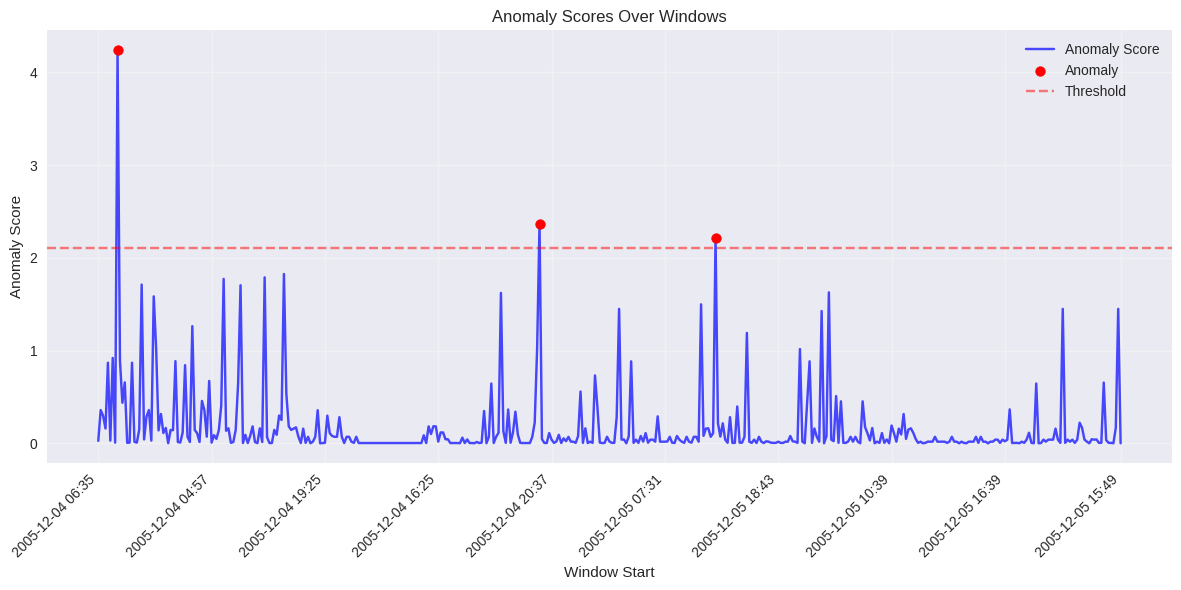

In [4]:
# Plot anomaly scores over time
plot_timeseries(anomalies)
plt.show()

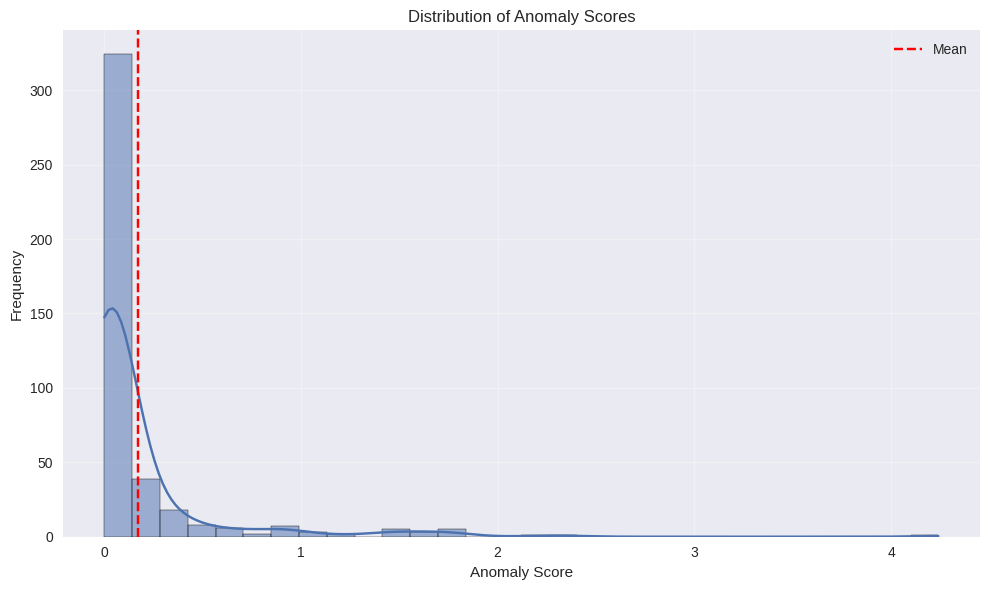

In [5]:
# Plot distribution of anomaly scores
plot_histogram(anomalies['AnomalyScore'])
plt.show()

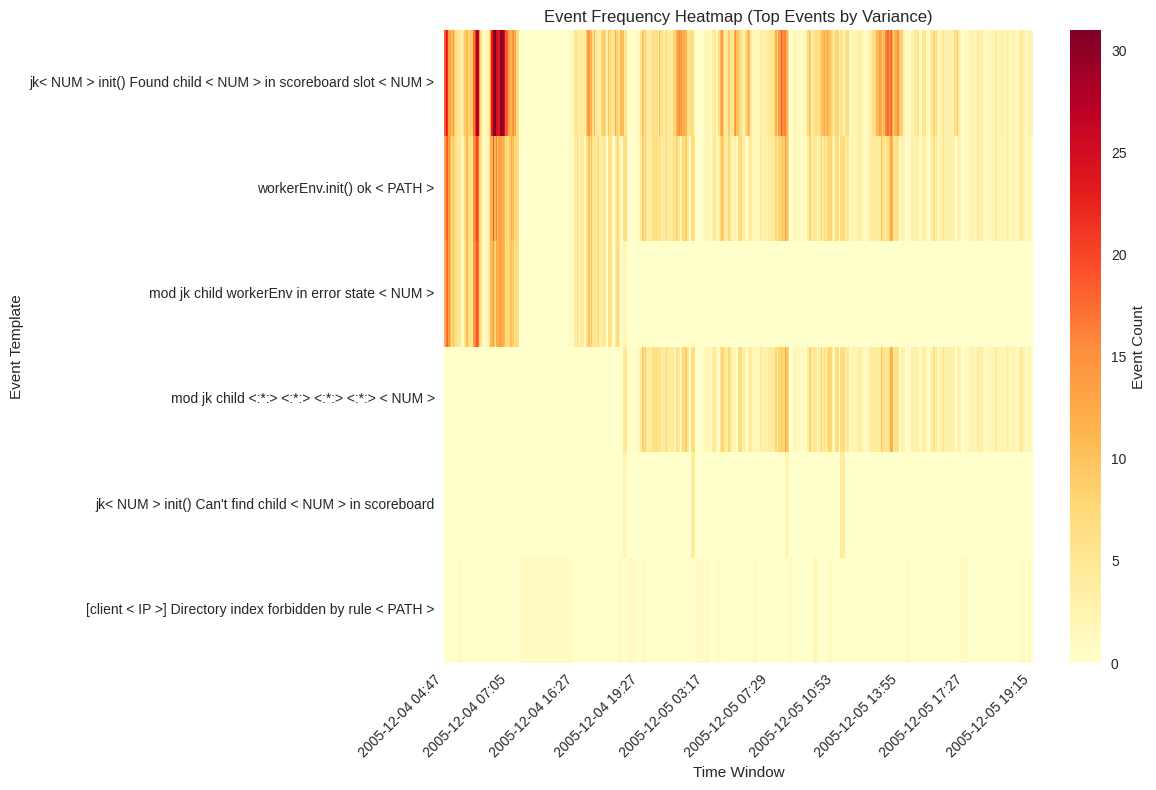

In [6]:
# Event heatmap
event_matrix = results['event_matrix']
plot_event_heatmap(event_matrix)
plt.show()

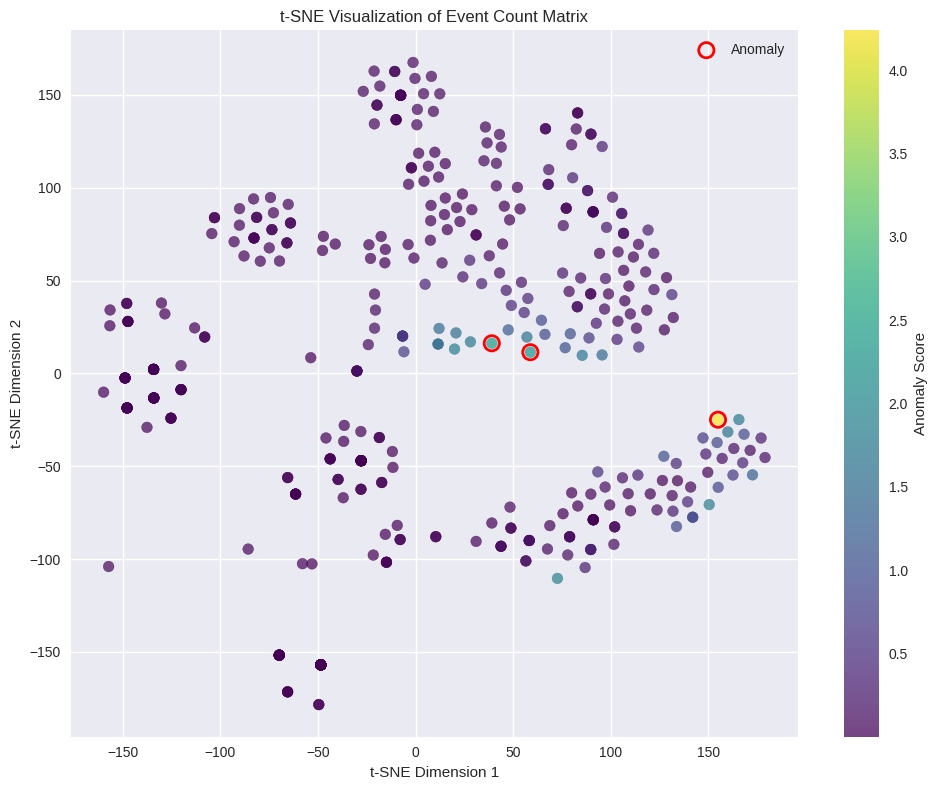

In [7]:
# t-SNE projection of event count matrix
plot_tsne(event_matrix, anomalies['AnomalyScore'], anomalies['IsAnomaly'])
plt.show()

In [ ]:
# dashboard
from pathlib import Path
import shutil

run_output_dir = Path(pipeline.output_dir)
dashboard_path = Path(create_analysis_dashboard(str(run_output_dir), output_format="png", interactive=True))
visuals_dir = Path(pipeline.config.output.directory) / "visuals"
visuals_dir.mkdir(exist_ok=True)
copied_dashboard = visuals_dir / dashboard_path.name
shutil.copy2(dashboard_path, copied_dashboard)
print(f"Dashboard saved to {copied_dashboard}")
